In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn yfinance

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [42]:
import yfinance as yf
import pandas as pd
import numpy as np

# ==========================================
# 1. DOWNLOAD FRESH DATA
# ==========================================

df = yf.download(
    "AAPL",
    start="2020-01-01",
    end="2026-01-01",
    auto_adjust=True
)

# ==========================================
# 2. FIX YFINANCE MULTIINDEX
# ==========================================

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# ==========================================
# 3. RESET INDEX
# ==========================================

df.reset_index(inplace=True)

# ==========================================
# 4. KEEP ONLY ORIGINAL COLUMNS
# ==========================================

df = df[
    ["Date", "Open", "High", "Low", "Close", "Volume"]
].copy()

# ==========================================
# 5. CHECK DATA
# ==========================================

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nFirst 5 rows:")
print(df.head())

print("\nMissing values:")
print(df.isnull().sum())

[*********************100%***********************]  1 of 1 completed

Shape: (1508, 6)

Columns:
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object', name='Price')

First 5 rows:
Price       Date       Open       High        Low      Close     Volume
0     2020-01-02  71.282575  72.331702  71.029923  72.271545  135480400
1     2020-01-03  71.501534  72.326874  71.345130  71.568909  146322800
2     2020-01-06  70.693051  72.177699  70.442799  72.139198  118387200
3     2020-01-07  72.148828  72.403889  71.580958  71.799927  108872000
4     2020-01-08  71.503945  73.255691  71.503945  72.954910  132079200

Missing values:
Price
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


In [43]:
df.columns.name = None

In [44]:
print(df.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')


In [45]:
print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nStatistical Summary:")
print(df.describe())

Dataset Shape: (1508, 6)

Data Types:
Date      datetime64[ns]
Open             float64
High             float64
Low              float64
Close            float64
Volume             int64
dtype: object

Statistical Summary:
                                Date         Open         High          Low  \
count                           1508  1508.000000  1508.000000  1508.000000   
mean   2022-12-30 16:01:35.490716160   164.333157   166.173689   162.648110   
min              2020-01-02 00:00:00    55.011864    55.113166    51.280570   
25%              2021-06-30 18:00:00   131.470033   132.521781   129.705031   
50%              2022-12-28 12:00:00   163.161494   165.029868   161.630804   
75%              2024-07-01 06:00:00   196.391098   198.948810   194.179747   
max              2025-12-31 00:00:00   285.423116   287.836529   282.530963   
std                              NaN    49.540650    49.874216    49.243945   

             Close        Volume  
count  1508.000000  1.508000e

In [46]:
print("Starting Date:", df["Date"].min())
print("Ending Date:", df["Date"].max())

Starting Date: 2020-01-02 00:00:00
Ending Date: 2025-12-31 00:00:00


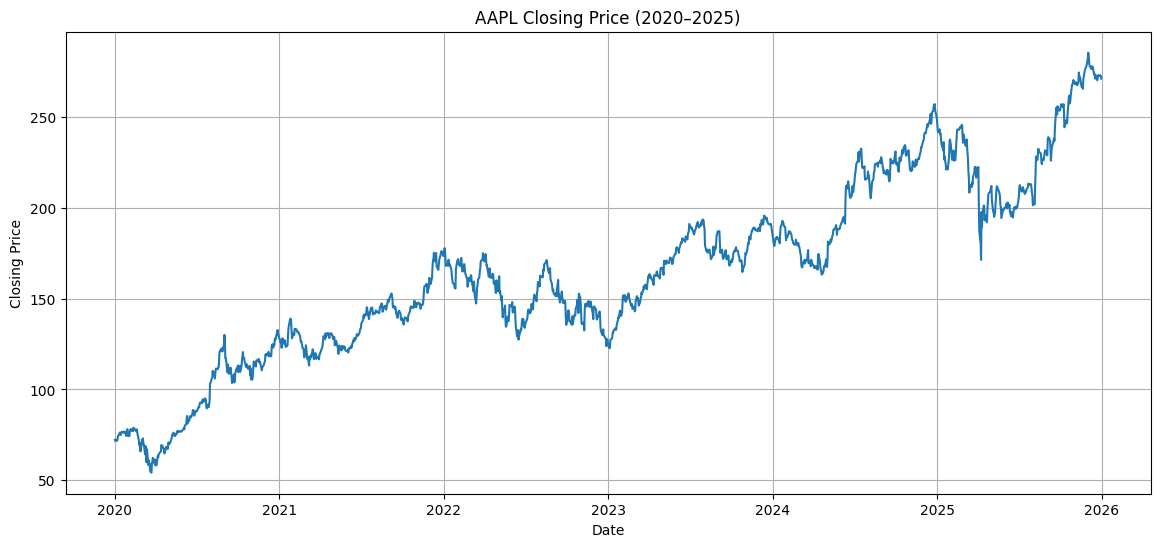

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    df["Date"],
    df["Close"]
)

plt.title("AAPL Closing Price (2020–2025)")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.grid(True)

plt.show()

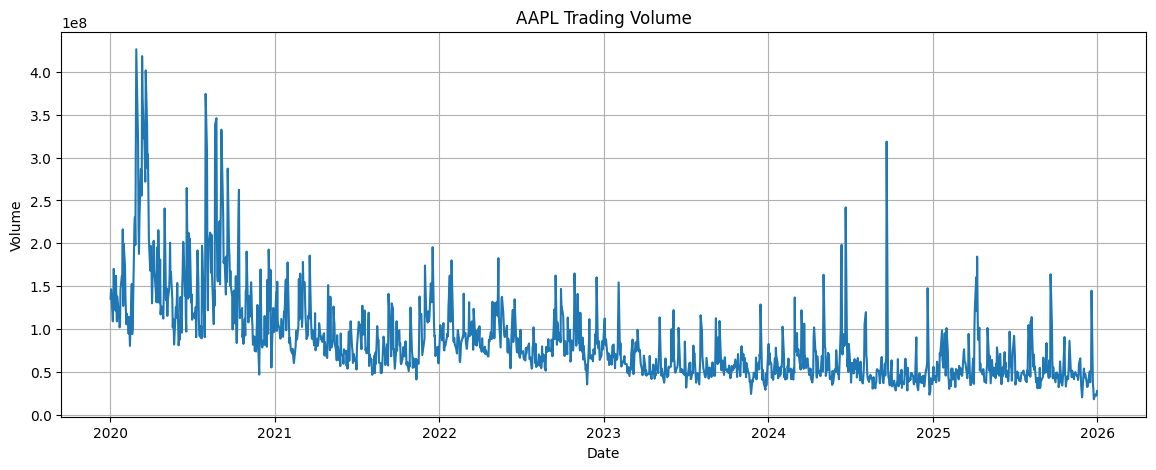

In [48]:
plt.figure(figsize=(14,5))

plt.plot(
    df["Date"],
    df["Volume"]
)

plt.title("AAPL Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")

plt.grid(True)

plt.show()

In [49]:
df["Daily_Return"] = df["Close"].pct_change()

In [50]:
print(df[["Date", "Close", "Daily_Return"]].head(10))

        Date      Close  Daily_Return
0 2020-01-02  72.271545           NaN
1 2020-01-03  71.568909     -0.009722
2 2020-01-06  72.139198      0.007968
3 2020-01-07  71.799927     -0.004703
4 2020-01-08  72.954910      0.016086
5 2020-01-09  74.504524      0.021241
6 2020-01-10  74.672958      0.002261
7 2020-01-13  76.268311      0.021365
8 2020-01-14  75.238441     -0.013503
9 2020-01-15  74.916008     -0.004285


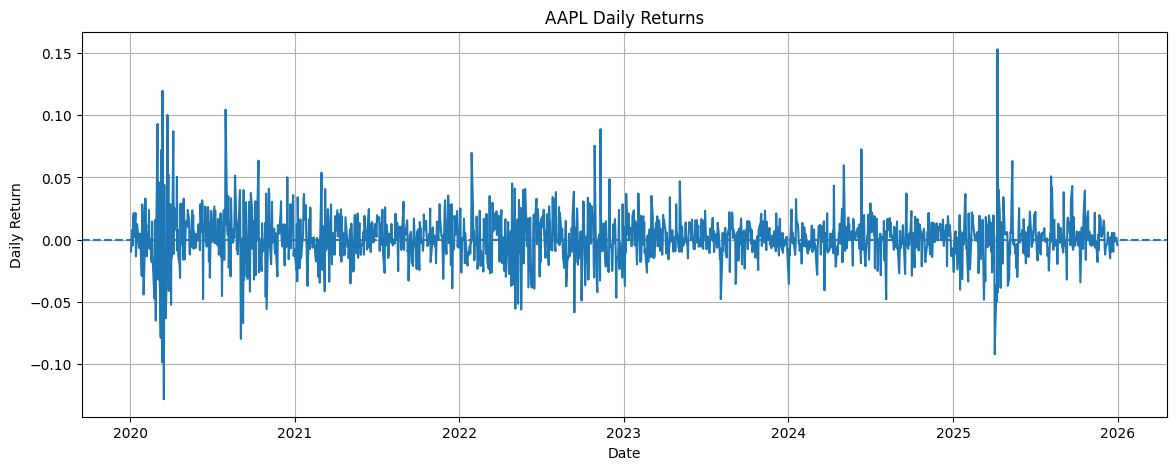

In [51]:
plt.figure(figsize=(14,5))

plt.plot(
    df["Date"],
    df["Daily_Return"]
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("AAPL Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.grid(True)

plt.show()

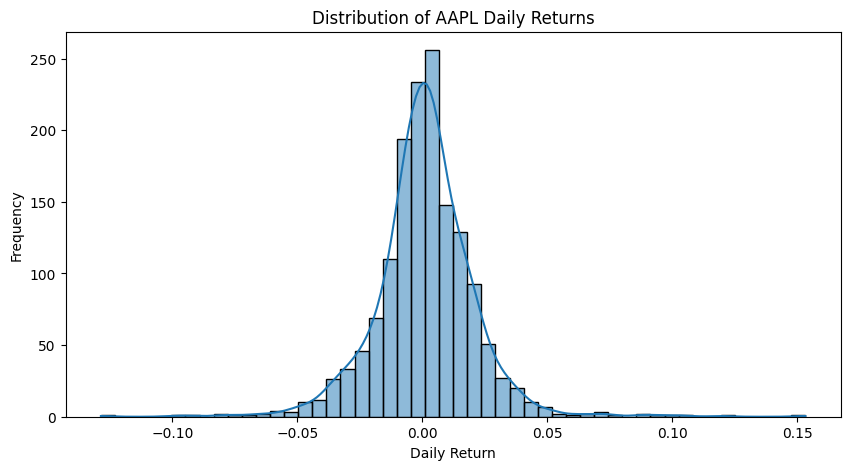

In [52]:
import seaborn as sns

plt.figure(figsize=(10,5))

sns.histplot(
    df["Daily_Return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of AAPL Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [53]:
df["MA5"] = df["Close"].rolling(window=5).mean()

df["MA20"] = df["Close"].rolling(window=20).mean()

df["MA50"] = df["Close"].rolling(window=50).mean()

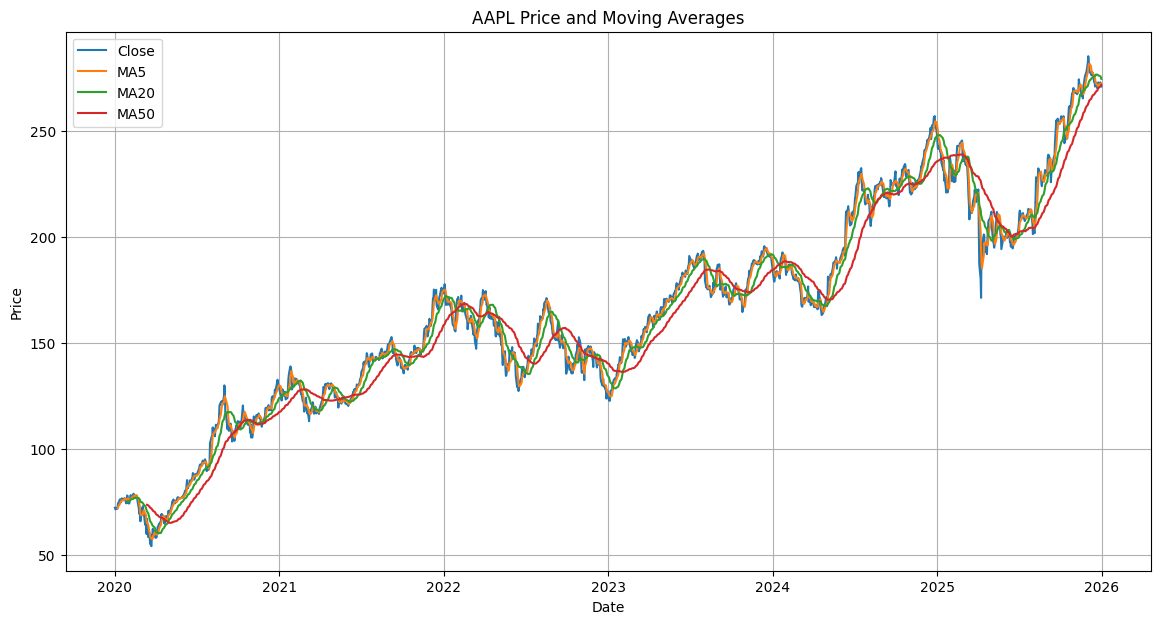

In [54]:
plt.figure(figsize=(14,7))

plt.plot(
    df["Date"],
    df["Close"],
    label="Close"
)

plt.plot(
    df["Date"],
    df["MA5"],
    label="MA5"
)

plt.plot(
    df["Date"],
    df["MA20"],
    label="MA20"
)

plt.plot(
    df["Date"],
    df["MA50"],
    label="MA50"
)

plt.title("AAPL Price and Moving Averages")

plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()

plt.grid(True)

plt.show()

In [55]:
df["Price_Range"] = df["High"] - df["Low"]

In [56]:
df["Open_Close_Diff"] = df["Close"] - df["Open"]

In [57]:
df["Previous_Close"] = df["Close"].shift(1)

In [58]:
print(df.shape)

print(df.head())

print("\nMissing values:")
print(df.isnull().sum())

(1508, 13)
        Date       Open       High        Low      Close     Volume  \
0 2020-01-02  71.282575  72.331702  71.029923  72.271545  135480400   
1 2020-01-03  71.501534  72.326874  71.345130  71.568909  146322800   
2 2020-01-06  70.693051  72.177699  70.442799  72.139198  118387200   
3 2020-01-07  72.148828  72.403889  71.580958  71.799927  108872000   
4 2020-01-08  71.503945  73.255691  71.503945  72.954910  132079200   

   Daily_Return        MA5  MA20  MA50  Price_Range  Open_Close_Diff  \
0           NaN        NaN   NaN   NaN     1.301779         0.988970   
1     -0.009722        NaN   NaN   NaN     0.981744         0.067375   
2      0.007968        NaN   NaN   NaN     1.734900         1.446148   
3     -0.004703        NaN   NaN   NaN     0.822931        -0.348901   
4      0.016086  72.146898   NaN   NaN     1.751745         1.450965   

   Previous_Close  
0             NaN  
1       72.271545  
2       71.568909  
3       72.139198  
4       71.799927  

Missing 

In [59]:
df["Target"] = df["Close"].shift(-1)

In [60]:
df.dropna()

,Date,Open,High,Low,Close,Volume,Daily_Return,MA5,MA20,MA50,Price_Range,Open_Close_Diff,Previous_Close,Target
49,2020-03-13,63.890279,67.515447,61.010400,67.045113,370732000,0.119808,65.274252,70.581877,73.669852,6.505047,3.154834,59.871956,58.419960
50,2020-03-16,58.357247,62.488923,57.886916,58.419960,322423600,-0.128647,64.118445,69.584051,73.392820,4.602007,0.062713,67.045113,60.988689
51,2020-03-17,59.698292,62.134364,57.501001,60.988689,324056000,0.043970,62.551640,68.786417,73.181215,4.633363,1.290397,58.419960,59.495697
52,2020-03-18,57.831449,60.298879,57.192279,59.495697,300233600,-0.024480,61.164283,67.858417,72.928345,3.106599,1.664248,60.988689,59.039833
53,2020-03-19,59.669353,60.983868,58.516439,59.039833,271857200,-0.007662,60.997858,66.947664,72.673144,2.467429,-0.629520,59.495697,55.291656
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1502,2025-12-23,270.104803,271.760301,268.828279,271.620667,29642000,0.005130,271.467084,276.557228,269.694871,2.932022,1.515863,270.234436,273.066711
1503,2025-12-24,271.600701,274.682309,271.461097,273.066711,17910600,0.005324,271.860016,276.399655,270.219043,3.221212,1.466011,271.620667,272.657806
1504,2025-12-26,273.415753,274.622460,272.119264,272.657806,21521800,-0.001497,272.101349,276.192717,270.703752,2.503196,-0.757947,273.066711,273.016876
1505,2025-12-29,271.949773,273.615223,271.610700,273.016876,23715200,0.001317,272.119299,275.938908,271.233304,2.004523,1.067103,272.657806,272.338684


In [61]:
print(df.isnull().sum())

Date                0
Open                0
High                0
Low                 0
Close               0
Volume              0
Daily_Return        1
MA5                 4
MA20               19
MA50               49
Price_Range         0
Open_Close_Diff     0
Previous_Close      1
Target              1
dtype: int64


In [62]:
df.dropna(inplace=True)

In [63]:
print(df.shape)
print(df.isnull().sum())

(1458, 14)
Date               0
Open               0
High               0
Low                0
Close              0
Volume             0
Daily_Return       0
MA5                0
MA20               0
MA50               0
Price_Range        0
Open_Close_Diff    0
Previous_Close     0
Target             0
dtype: int64


In [64]:
features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "Daily_Return",
    "MA5",
    "MA20",
    "MA50",
    "Price_Range",
    "Open_Close_Diff",
    "Previous_Close"
]
X = df[features]
y = df["Target"]

In [65]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1458, 12)
y shape: (1458,)


In [66]:
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [67]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1166, 12)
X_test: (292, 12)
y_train: (1166,)
y_test: (292,)


In [68]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [69]:
y_pred = model.predict(X_test)

In [70]:
print("Actual:", y_test.values[:10])
print("Predicted:", y_pred[:10])

Actual: [224.03588867 221.06077576 220.16824341 221.59628296 220.87236023
 225.59288025 225.3248291  222.61448669 222.61448669 223.49804688]
Predicted: [227.7731707  223.5958817  221.42321174 220.37543414 221.93938592
 221.09135818 226.03146415 225.43886789 221.87632268 222.79729372]


In [71]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 2.753744977037808


In [72]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

print("RMSE:", rmse)

RMSE: 4.124426562900558


In [73]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.9727828420325014


In [74]:
print("===== MODEL PERFORMANCE =====")

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

===== MODEL PERFORMANCE =====
MAE  : 2.75
RMSE : 4.12
R²   : 0.9728


In [76]:
test_dates = df["Date"].iloc[split:]

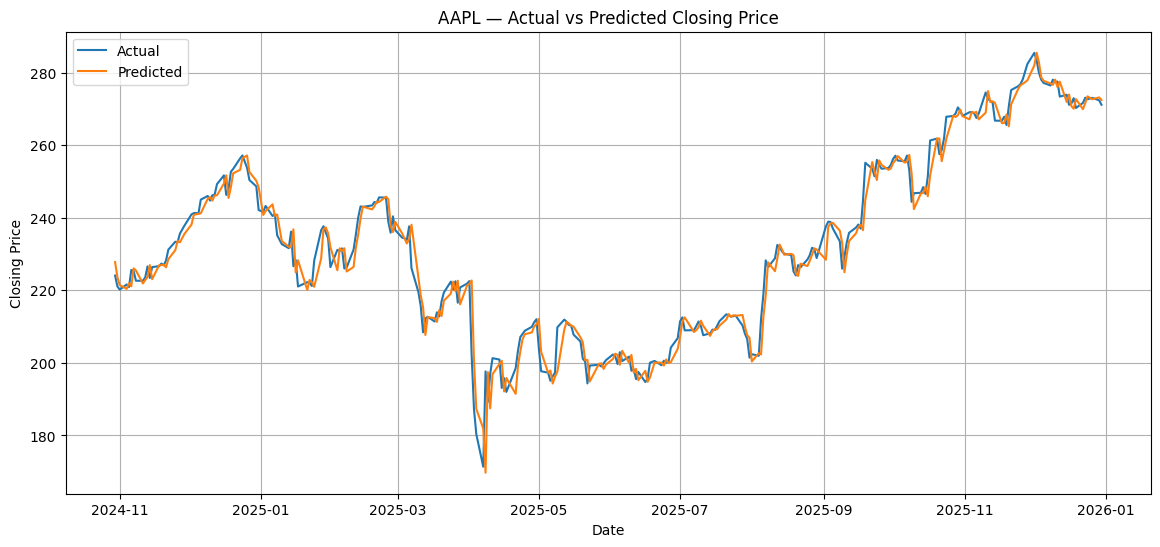

In [77]:
plt.figure(figsize=(14,6))

plt.plot(
    test_dates,
    y_test.values,
    label="Actual"
)

plt.plot(
    test_dates,
    y_pred,
    label="Predicted"
)

plt.title("AAPL — Actual vs Predicted Closing Price")

plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.legend()

plt.grid(True)

plt.show()

In [78]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

print(coefficients)

            Feature   Coefficient
3             Close  6.170294e-01
10  Open_Close_Diff  4.359169e-01
2               Low  2.325406e-01
0              Open  1.811126e-01
1              High  1.608863e-01
6               MA5  5.374723e-02
7              MA20  6.451235e-03
4            Volume  1.081349e-10
8              MA50 -1.240635e-03
9       Price_Range -7.165437e-02
11   Previous_Close -2.529940e-01
5      Daily_Return -3.643624e+01


In [79]:
from sklearn.ensemble import RandomForestRegressor

In [80]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [81]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

In [82]:
rf_pred = rf_model.predict(X_test)

In [83]:
print("Actual:")
print(y_test.values[:10])

print("\nRandom Forest Prediction:")
print(rf_pred[:10])

Actual:
[224.03588867 221.06077576 220.16824341 221.59628296 220.87236023
 225.59288025 225.3248291  222.61448669 222.61448669 223.49804688]

Random Forest Prediction:
[228.77127518 225.72334503 219.79700897 219.58468613 220.47775284
 219.41297165 226.81498932 227.68125336 222.371633   223.71094131]


In [84]:
rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

In [85]:
rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

In [86]:
rf_r2 = r2_score(
    y_test,
    rf_pred
)

In [87]:
print("===== RANDOM FOREST =====")

print(f"MAE  : {rf_mae:.4f}")
print(f"RMSE : {rf_rmse:.4f}")
print(f"R²   : {rf_r2:.4f}")

===== RANDOM FOREST =====
MAE  : 13.2796
RMSE : 19.5514
R²   : 0.3884


In [89]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

In [90]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [91]:
print(feature_importance)

            Feature  Importance
3             Close    0.658875
2               Low    0.132049
1              High    0.112524
0              Open    0.034128
7              MA20    0.019708
6               MA5    0.018357
8              MA50    0.015780
11   Previous_Close    0.006889
4            Volume    0.000499
9       Price_Range    0.000419
5      Daily_Return    0.000395
10  Open_Close_Diff    0.000377


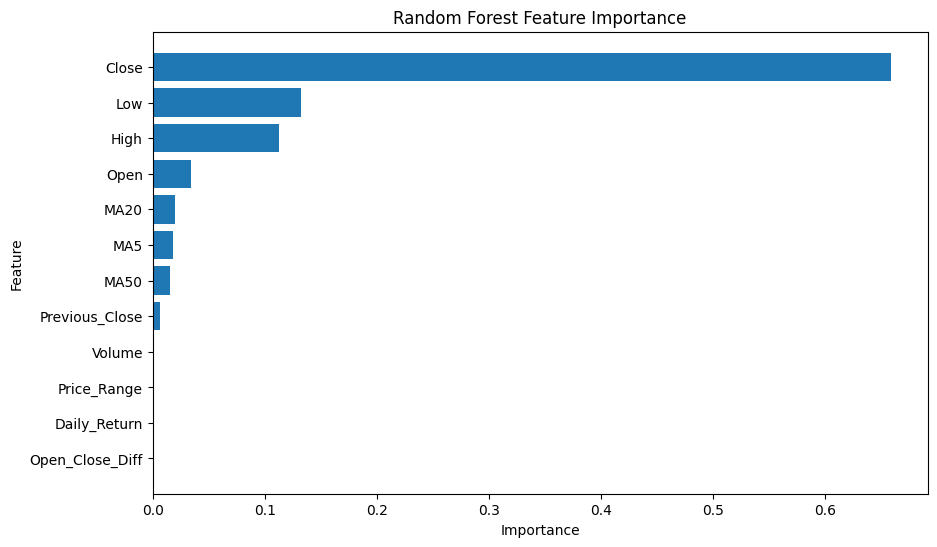

In [92]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

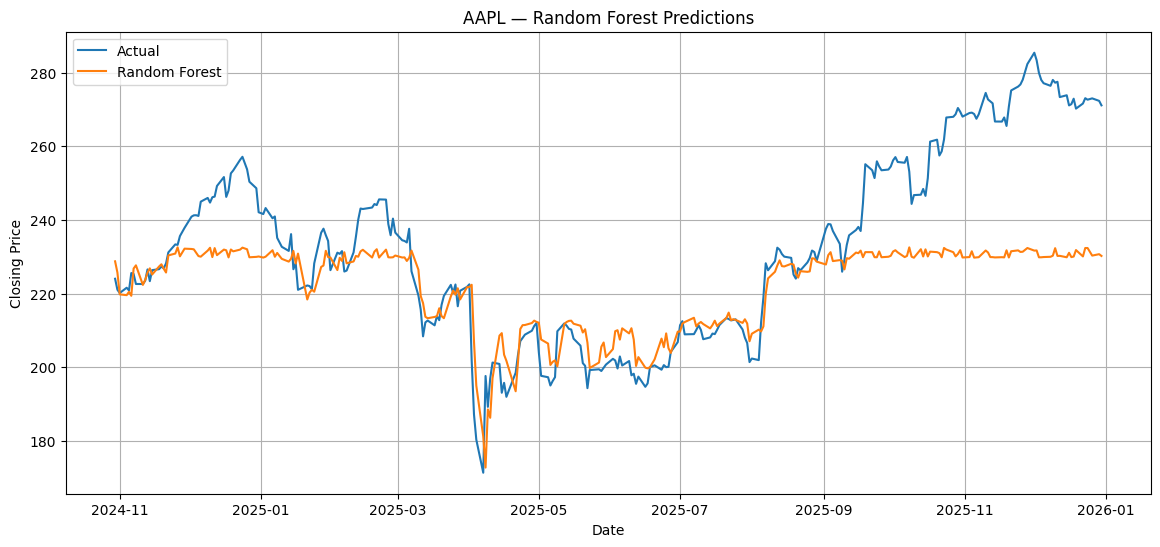

In [93]:
test_dates = df["Date"].iloc[split:]

plt.figure(figsize=(14,6))

plt.plot(
    test_dates,
    y_test.values,
    label="Actual"
)

plt.plot(
    test_dates,
    rf_pred,
    label="Random Forest"
)

plt.title("AAPL — Random Forest Predictions")

plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.legend()

plt.grid(True)

plt.show()

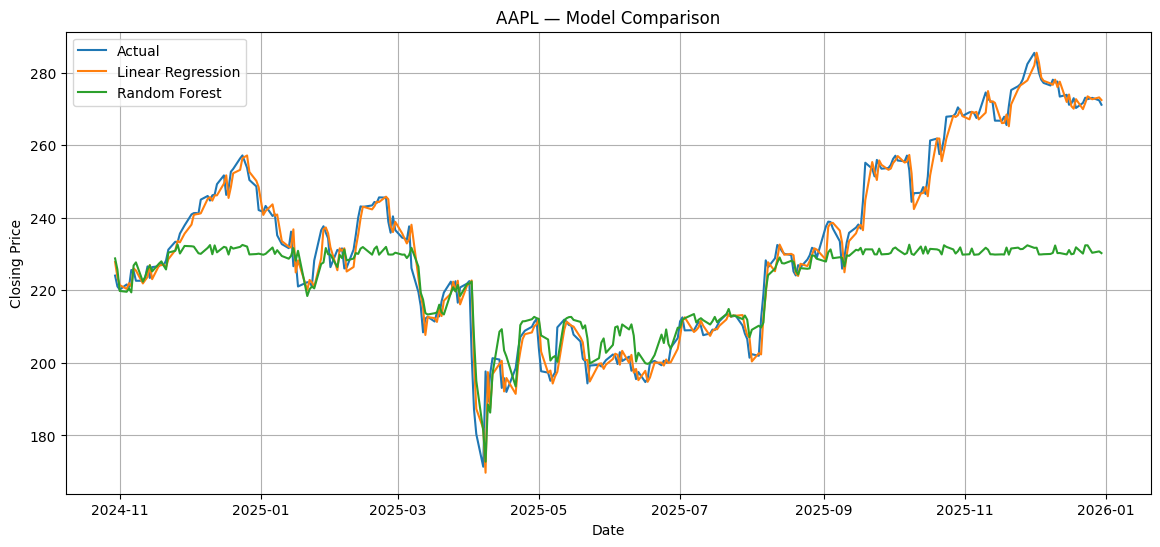

In [94]:
plt.figure(figsize=(14,6))

plt.plot(
    test_dates,
    y_test.values,
    label="Actual"
)

plt.plot(
    test_dates,
    y_pred,
    label="Linear Regression"
)

plt.plot(
    test_dates,
    rf_pred,
    label="Random Forest"
)

plt.title("AAPL — Model Comparison")

plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.legend()

plt.grid(True)

plt.show()